In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

In [3]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Dataset overview
The dataset contains information about loan applicants including their demographic details, financial status, and loan-related attributes.

- total records: 32581
- features include age, income, intent,loan amount, interest rate and credit history
- target variable: **loan_status** (0= Not Approved, 1 = Approved)

the dataset contains both numeric and non-numeric features, making it sutable for classification tasks 

In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Data cleaning

- Missing values were identified in:
  - `person_emp_length`
  - `loan_int_rate`

In [6]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28638 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  28638 non-null  int64  
 1   person_income               28638 non-null  int64  
 2   person_home_ownership       28638 non-null  object 
 3   person_emp_length           28638 non-null  float64
 4   loan_intent                 28638 non-null  object 
 5   loan_grade                  28638 non-null  object 
 6   loan_amnt                   28638 non-null  int64  
 7   loan_int_rate               28638 non-null  float64
 8   loan_status                 28638 non-null  int64  
 9   loan_percent_income         28638 non-null  float64
 10  cb_person_default_on_file   28638 non-null  object 
 11  cb_person_cred_hist_length  28638 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.8+ MB


After removing missing values in `person_emp_length` and`loan_int_rate` we were left with 28638 rows 

## EDA

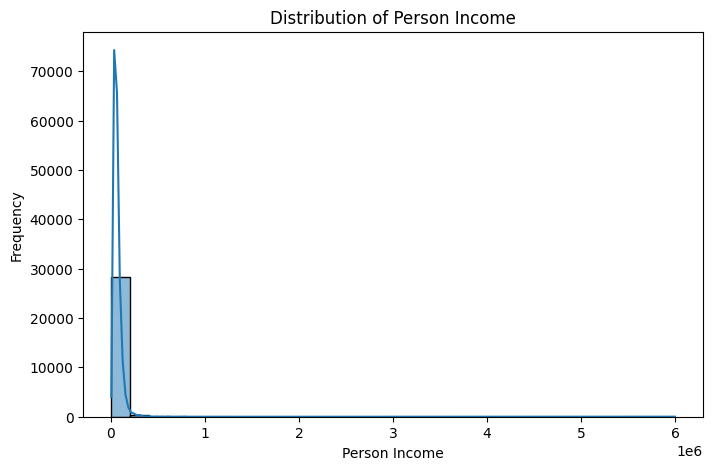

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=30, kde=True)
plt.title('Distribution of Person Income')
plt.xlabel('Person Income')
plt.ylabel('Frequency')
plt.show()

- Outliers were present in `person_income`

In [8]:
df = df[df['person_income'] < df['person_income'].quantile(0.99)]

Extreme income values (top 1%) were removed

### Distribution of Person Income

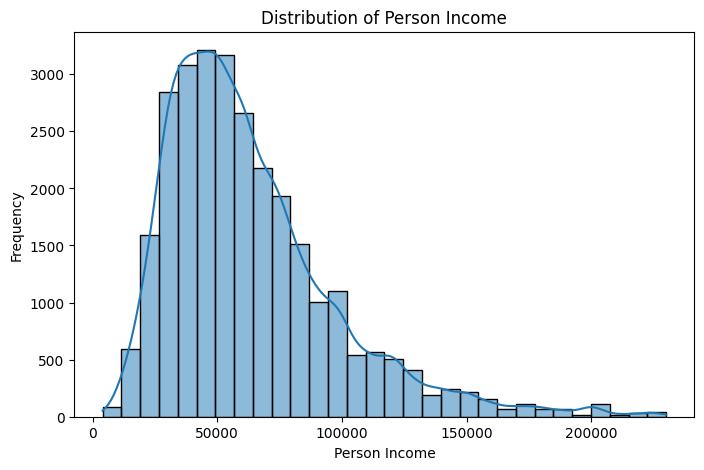

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=30, kde=True)
plt.title('Distribution of Person Income')
plt.xlabel('Person Income')
plt.ylabel('Frequency')
plt.show()

This distribution is highly right-skewed
- most applicants fall in low to mid income range
- few applicants fall in high income range

This indicates income inequlity among applicants.

### Distribution of Loan Amount

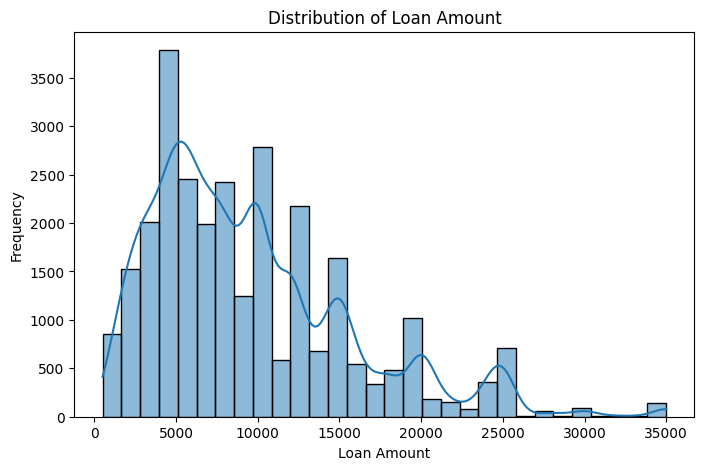

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

This distribution is slightly right-skewed
- Loan amounts are concentrated rated in lower range.
- Few applicants apply for high loans

This suggest borrowers prefers smaller loan amount

### Distribution of Loan Interest Rate

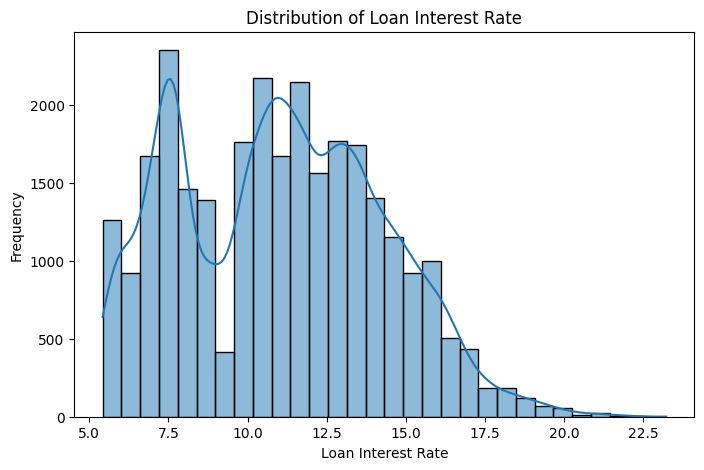

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_int_rate'], bins=30, kde=True)
plt.title('Distribution of Loan Interest Rate')
plt.xlabel('Loan Interest Rate')
plt.ylabel('Frequency')
plt.show()

The distribution is slightly right-sked
- Most interest rates lie between 7% to 15%
- Higher interest rates are less frequent

This indicates moderate risk levels for most loans.

### Loan Status Distribution

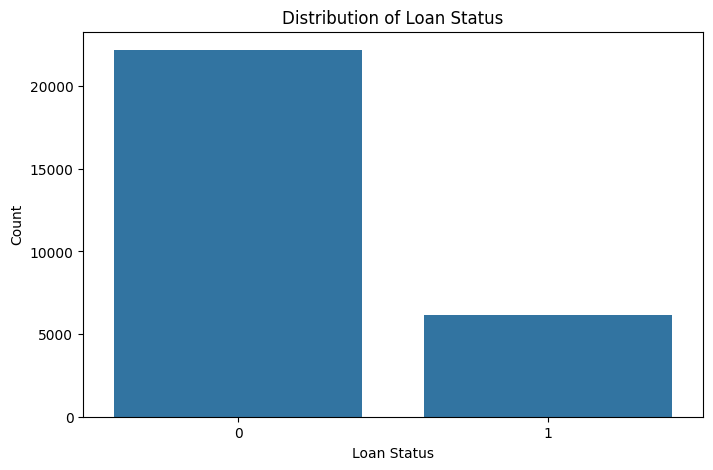

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x="loan_status", data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()



- Majority of loans are not approved (0)
- Fewer loans are approved (1)

This shows class imbalance in the dataset, which may affect model performance.

### Distribution of Loan Grade

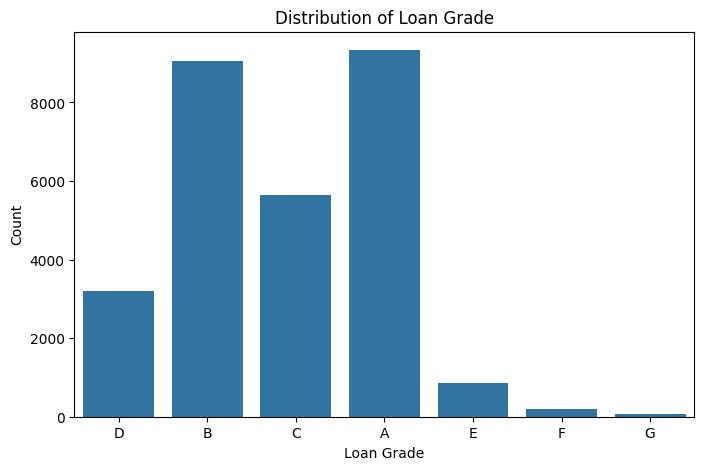

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="loan_grade", data=df)
plt.title('Distribution of Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()

- Most loans fall under grades A, B, and C
- Very few loans are in high-risk categories like F and G

This indicates that most applicants are relatively low to medium risk.

### istribution of Loan Intent

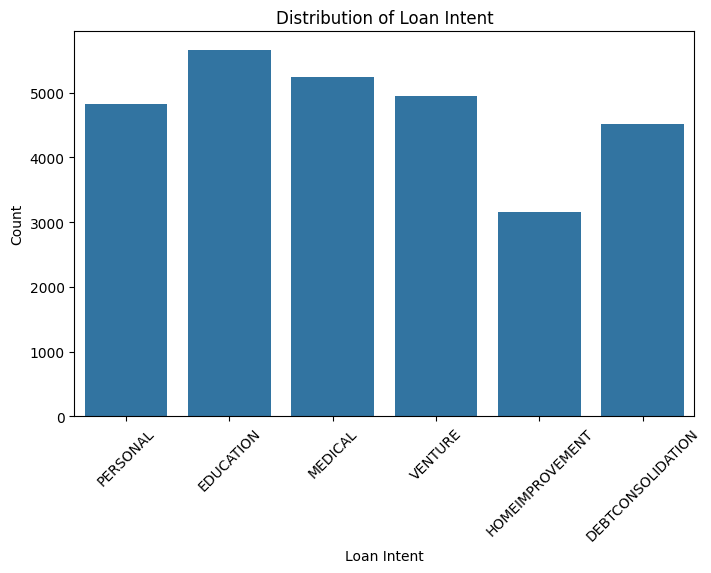

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="loan_intent", data=df)
plt.title('Distribution of Loan Intent')
plt.xlabel('Loan Intent')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

- Most common purposes include:
   - Education
   - Medical
   - Venture 
- lest common:
    - Homeimprovement

This shows the primary reasons why people apply for loans.

### Distribution of Home Ownership

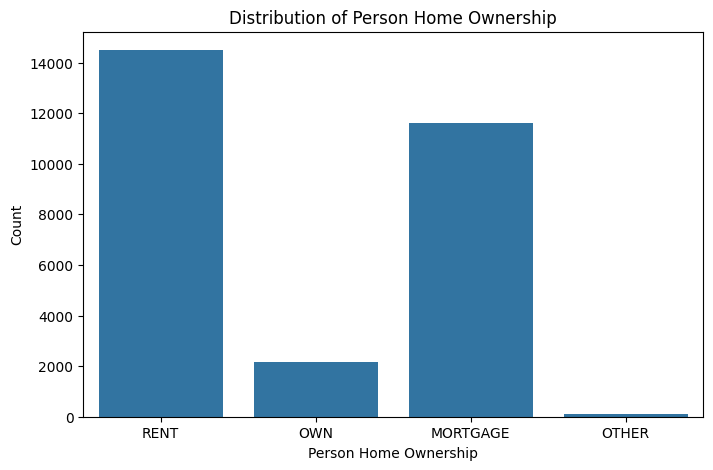

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x="person_home_ownership", data=df)
plt.title('Distribution of Person Home Ownership')
plt.xlabel('Person Home Ownership')
plt.ylabel('Count')
plt.show()

- Most applicants ether Rent or have their home on mortgage
- few applicants have their own home

This suggests that many applicants are financially dependent on housing loans or rent.

### Person Income vs Loan Amount (by Loan Status)

This scatter plot shows the relationship between applicant income and loan amount, categorized by loan status.

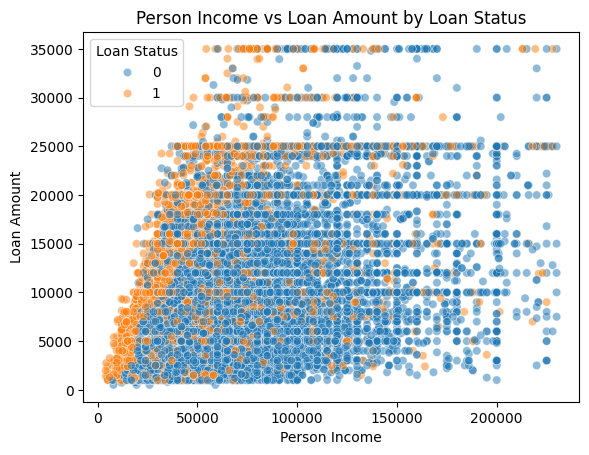

In [16]:
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df, alpha=0.5)
plt.title('Person Income vs Loan Amount by Loan Status')
plt.xlabel('Person Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')
plt.show()


#### Key Observations:
- Most applicants fall in the low to mid income range (below 100,000)
- Loan amount generally increases with income (positive relationship)
- Approved (1) and not approved (0) loans are mixed across the plot
- Higher income does not guarantee loan approval
- Some applicants with lower income still receive loans, indicating other factors (like credit history) are important

#### Conclusion:
Income alone is not a strong predictor of loan approval. Other features such as credit history and loan percentage income play a more significant role.

### Person Income vs Loan Status

This boxplot compares the distribution of applicant income based on loan status.


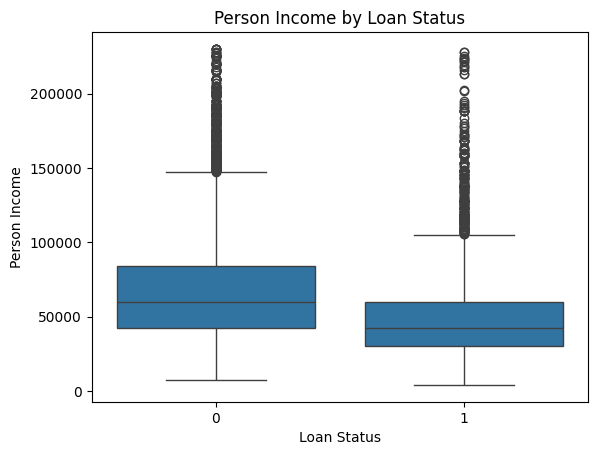

In [17]:
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title('Person Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Person Income')
plt.show()


#### Key Observations:
- Median income of rejected (0) applicants is slightly higher than approved (1)
- Both categories show a wide spread of income values
- Significant number of outliers present in both groups
- Income ranges overlap heavily between approved and rejected loans

#### Conclusion:
Income alone does not clearly distinguish between approved and rejected loans.  
There is no strong separation, indicating that other factors play a more important role in loan approval decisions.

Even applicants with higher income can be rejected, possibly due to poor credit history or high loan burden.

### Loan percentage of Income vs Loan Status


This boxplot shows the relationship between loan burden (loan as a percentage of income) and loan approval status.

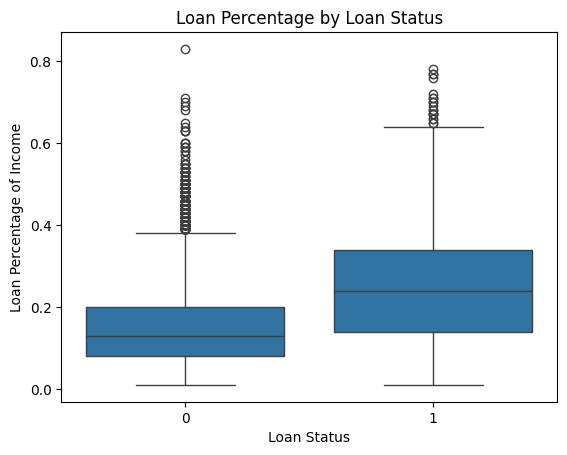

In [18]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title('Loan Percentage by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percentage of Income')
plt.show()

#### Key Observations:
- Approved (1) applicants have a higher median loan percentage compared to rejected (0)
- The spread of loan percentage is wider for approved loans
- Rejected applicants generally have lower loan percentage values
- Significant overlap exists, but approved loans tend to have higher loan burden

#### Conclusion:
Loan percentage of income is an important factor in loan approval decisions.  
Applicants with higher loan-to-income ratios are more likely to be approved, suggesting lenders consider proportional income rather than absolute income.

Although approved applicants show higher median values, the overlap suggests that loan approval depends on multiple factors such as credit history and loan grade, not just loan percentage.

### Correlation Heatmap

The heatmap shows the correlation between numerical features in the dataset.


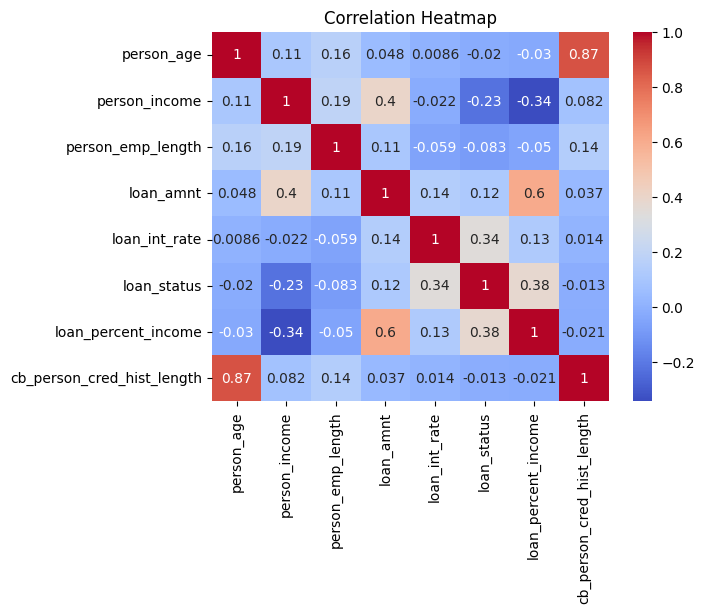

In [19]:
sns.heatmap( df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



#### Key Observations:
- `loan_percent_income` has a strong positive correlation with `loan_amnt` (~0.6)
- `loan_status` shows moderate correlation with:
  - `loan_percent_income` (~0.38)
  - `loan_int_rate` (~0.34)
- `person_income` has a negative correlation with `loan_percent_income` (~ -0.34)
- `person_age` and `cb_person_cred_hist_length` are highly correlated (~0.87)

#### Insights:
- Loan burden (`loan_percent_income`) is an important factor for loan approval
- Higher interest rates are associated with higher chances of loan approval/rejection patterns
- Income reduces relative loan burden

#### Conclusion:
No extremely strong correlations with the target variable are observed, indicating that loan approval depends on multiple features rather than a single factor.

There is no strong multicollinearity between most features, making the dataset suitable for machine learning models.

### Income Bins vs Loan Status

This plot shows the distribution of loan approval across different income groups.



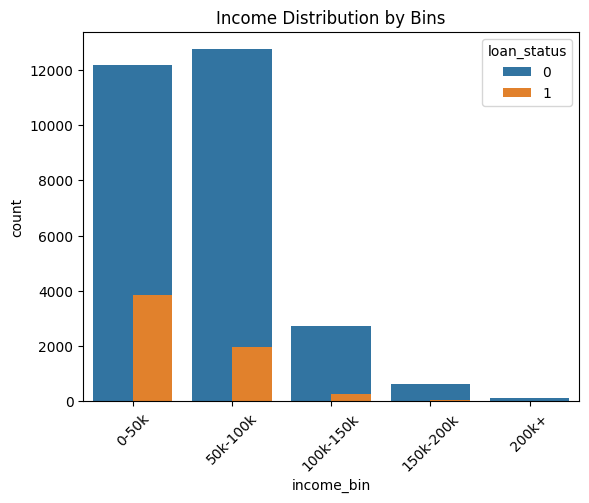

In [20]:
bins = [0, 50000, 100000, 150000, 200000, 300000]
labels = ['0-50k', '50k-100k', '100k-150k', '150k-200k', '200k+']

df['income_bin'] = pd.cut(df['person_income'], bins=bins, labels=labels)

sns.countplot(x='income_bin', data=df)
plt.title('Income Distribution by Bins')
plt.xticks(rotation=45)
sns.countplot(x='income_bin', data=df, hue='loan_status')
plt.show()


#### Key Observations:
- Most applicants belong to the 0–100k income range
- Rejected loans (0) are significantly higher across all income groups
- Approved loans (1) are fewer in every income category
- Higher income groups (above 150k) have very few applicants and very few approvals

#### Insights:
- Loan approval is not strongly dependent on income alone
- Even in higher income groups, approvals are limited
- Lower income groups still have a noticeable number of approvals

#### Conclusion:
Income level alone does not determine loan approval.  
Other factors such as credit history, loan percentage, and loan grade play a more significant role.

The dataset shows class imbalance, with more rejected loans than approved ones, which should be considered during model training.

## ML

In [21]:
y = df['loan_status']
X = df.drop('loan_status', axis=1)

In [22]:
X = pd.get_dummies(X, drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### RandomForest Classification

In [24]:
rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


### Final Model Performance for RandomForest 



In [25]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
cs = classification_report(y_test, y_pred)
print(cs)

Accuracy: 0.9366954681713984
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4490
           1       0.97      0.72      0.82      1181

    accuracy                           0.94      5671
   macro avg       0.95      0.86      0.89      5671
weighted avg       0.94      0.94      0.93      5671



The Random Forest model achieved an accuracy of 93.67%, indicating strong overall performance.


#### Key Observations:
- The model performs exceptionally well in predicting non-approved loans (recall = 0.99)
- Precision for approved loans is high (0.97), meaning predictions are highly reliable
- Recall for approved loans is lower (0.72), indicating some approved cases are misclassified

#### Insights:
- The model is slightly biased towards the majority class
- It is conservative in approving loans, minimizing risky approvals
- However, some valid applicants are incorrectly rejected

#### Conclusion:
The model provides strong performance and reliable predictions.  
Further improvements can be made by handling class imbalance to improve recall for approved loans.

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of model predictions.


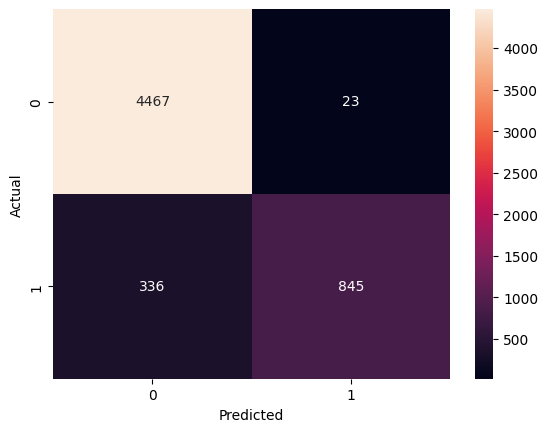

In [26]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### Results:
- True Negatives (0 → 0): 4467
- True Positives (1 → 1): 845
- False Positives (0 → 1): 23
- False Negatives (1 → 0): 336

#### Key Observations:
- The model correctly predicts most non-approved loans
- Very few false positives → strong precision
- However, there are a significant number of false negatives

#### Insights:
- The model is conservative in approving loans
- It tends to classify some approved loans as rejected

#### Conclusion:
While the model performs well overall, improving the detection of approved loans (reducing false negatives) is necessary for better balance.

### SVM

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
svm = SVC(kernel='rbf', class_weight='balanced',random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

### Final Model Performance for Support Vector machine 


In [29]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
cs_svm = classification_report(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)
print("SVM Classification Report:", cs_svm)


SVM Accuracy: 0.8853817668841474
SVM Classification Report:               precision    recall  f1-score   support

           0       0.93      0.92      0.93      4490
           1       0.71      0.75      0.73      1181

    accuracy                           0.89      5671
   macro avg       0.82      0.84      0.83      5671
weighted avg       0.89      0.89      0.89      5671




#### Observations:
- Random Forest achieved higher accuracy (~93.6%)
- SVM achieved lower accuracy (~88.5%)
- SVM showed better recall for approved loans (class 1)

#### Insights:
- Random Forest is more accurate and reliable overall
- SVM performs better in identifying approved loans
- Trade-off exists between accuracy and recall

#### Conclusion:
Random Forest is selected as the final model due to its higher overall performance.  
However, SVM demonstrates better capability in detecting approved loans.

### SVM Confusion Matrix Analysis

The confusion matrix shows the performance of the SVM model.


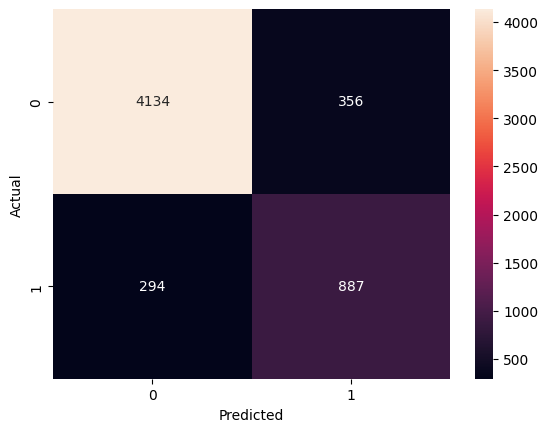

In [30]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### Results:
- True Negatives: 4134
- True Positives: 887
- False Positives: 356
- False Negatives: 294

#### Key Observations:
- The model correctly predicts most non-approved loans
- Higher false positives compared to Random Forest
- Lower false negatives compared to Random Forest

#### Insights:
- SVM is more aggressive in predicting approvals
- It captures more approved cases (better recall)
- However, it increases the risk of incorrect approvals

#### Conclusion:
SVM improves detection of approved loans but at the cost of more false positives.  
This creates a trade-off between safety and coverage.

### Model Comparison

Two models were evaluated: Random Forest and Support Vector Machine (SVM).

### ROC-AUC Comparison

ROC-AUC scores were calculated to evaluate model performance across thresholds.


In [33]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC for Random Forest:", roc_auc_score(y_test, y_prob))
y_prob_svm = svm.decision_function(X_test_scaled)
print("ROC-AUC for SVM:", roc_auc_score(y_test, y_prob_svm))

ROC-AUC for Random Forest: 0.9370013144272058
ROC-AUC for SVM: 0.9067676971499371



#### Results:
- Random Forest: 0.94
- SVM: 0.91

#### Insights:
- SVM significantly outperforms Random Forest in ROC-AUC
- This indicates that SVM has a better ability to distinguish between approved and non-approved loans
- However, Random Forest achieves higher accuracy and lower false positives

#### Final Conclusion:
While SVM shows superior ROC-AUC performance, Random Forest is selected as the final model due to its higher accuracy and safer predictions.

### ROC Curve Comparison (Random Forest vs SVM)

The ROC curves compare the performance of Random Forest and SVM models across different thresholds.


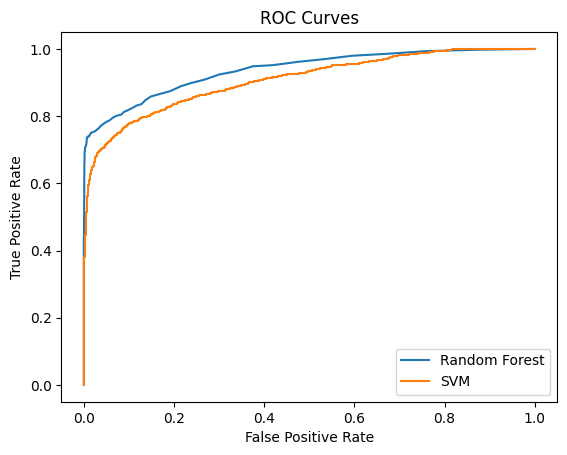

In [34]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

### ROC Curve Comparison

The ROC curves compare Random Forest and SVM performance.

#### Key Observations:
- Both models perform very well, with curves close to the top-left corner
- Random Forest slightly outperforms SVM across most thresholds
- Both models are significantly better than random guessing

#### Insights:
- Random Forest has a slightly higher ability to distinguish between classes
- SVM also performs strongly but is marginally lower

#### Conclusion:
Random Forest performs slightly better than SVM in ROC-AUC, reinforcing its selection as the final model.

## Final Evaluation

This project aimed to predict loan approval using machine learning techniques. A complete pipeline was implemented including data cleaning, exploratory data analysis (EDA), feature engineering, and model building.

### Models Used:
- Random Forest Classifier
- Support Vector Machine (SVM)

### Performance Summary:

#### Random Forest:
- Accuracy: 93.67%
- Strong performance in predicting non-approved loans
- Very low false positives (safe model)
- Moderate recall for approved loans

#### SVM:
- Accuracy: 88.5%
- Better recall for approved loans
- Higher false positives compared to Random Forest
- Superior ROC-AUC score (0.91)

### Key Insights:
- Loan approval is influenced by multiple factors such as loan percentage of income, interest rate, and credit history
- Income alone is not a strong predictor
- The dataset is imbalanced, affecting model performance
- Trade-off exists between accuracy and recall across models

### Model Comparison:
- Random Forest achieved higher accuracy and safer predictions
- SVM showed better ability to distinguish between classes (higher ROC-AUC)
- Random Forest minimizes risk, while SVM improves detection of approvals

### Final Model Selection:
Random Forest is selected as the final model due to:
- Higher accuracy
- Lower false positives
- More reliable and stable performance

### Conclusion:
The project successfully demonstrates how machine learning can be used to predict loan approval.  
The Random Forest model provides a strong balance between performance and reliability, making it suitable for real-world applications.

Future improvements may include:
- Handling class imbalance using advanced techniques (SMOTE)
- Hyperparameter tuning
- Using ensemble or boosting methods